# Random Forest — Prediction du prix median immobilier

**Modele** : Random Forest Regressor (ensemble d'arbres de decision)

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

ou $B$ est le nombre d'arbres et $T_b(x)$ la prediction de l'arbre $b$.

**Pipeline** :
1. Chargement des donnees nettoyees (imputees, sans outliers, normalisees Z-Score)
2. Analyse de colinearite et selection des features
3. Train/test split (70/30)
4. Entrainement du modele Random Forest
5. Importance des features
6. Evaluation de la precision via la **moyenne** et l'**ecart-type** des erreurs (%)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('./datasets/amputed_normalized_housing_data.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (17601, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.315977,0.995320,1.83728,-0.622220,-1.156299,-1.161352,-1.168233,2.620165,352100.0,1.300935
1,-1.320967,0.995320,1.83728,-0.799883,-0.953182,-1.058970,-0.964205,1.477758,341300.0,1.300935
2,-1.320967,0.995320,1.83728,-0.474934,-0.750065,-1.047410,-0.769893,0.206130,342200.0,1.300935
3,-1.320967,0.995320,1.83728,-1.126674,-1.052484,-1.298413,-1.090508,0.341013,269700.0,1.300935
4,-1.320967,0.990705,1.83728,0.360912,0.193300,-0.173855,0.468851,0.073723,299200.0,1.300935


## Donnees d'entree / sortie

**Entree** : `datasets/amputed_normalized_housing_data.csv` (17 601 lignes, 10 colonnes)

| Colonne | Type | Description |
|---------|------|-------------|
| `longitude` | float (Z-Score) | Coordonnee geographique |
| `latitude` | float (Z-Score) | Coordonnee geographique |
| `housing_median_age` | float (Z-Score) | Age median des logements |
| `total_rooms` | float (Z-Score) | Nombre total de pieces |
| `total_bedrooms` | float (Z-Score) | Nombre total de chambres |
| `population` | float (Z-Score) | Population du bloc |
| `households` | float (Z-Score) | Nombre de menages |
| `median_income` | float (Z-Score) | Revenu median (en 10k$) |
| `ocean_proximity` | float (Z-Score) | Proximite a l'ocean (encodage ordinal normalise) |

**Cible (sortie)** : `median_house_value` — prix median immobilier en **dollars** (non normalise, valeurs brutes entre ~80k$ et ~500k$)

Apres analyse de colinearite, **5 features** sont conservees : `latitude`, `housing_median_age`, `total_rooms`, `median_income`, `ocean_proximity`.

## 1. Analyse de colinearite

On identifie les paires de features avec $|r| > 0.8$ (fortement correlees).  
Pour chaque paire, on supprime la feature la moins correlee avec la cible.

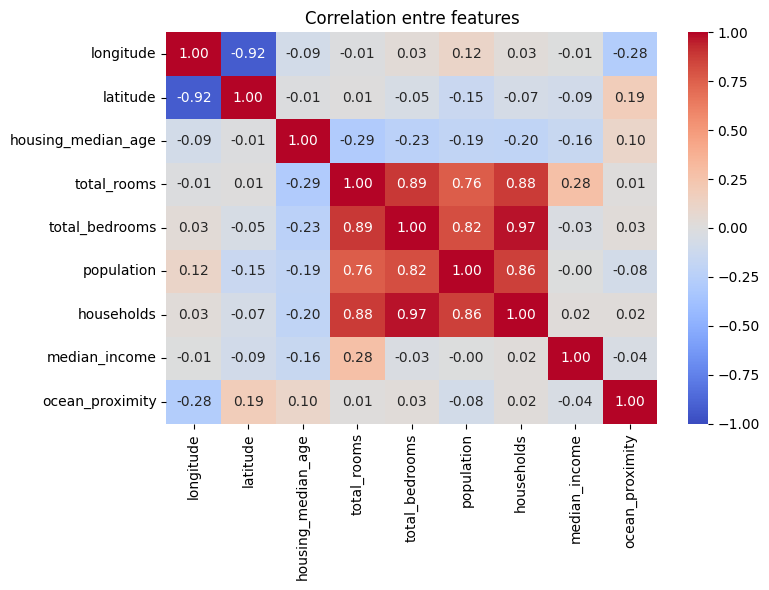


Paires avec |r| > 0.8 :
  longitude <-> latitude : r = -0.923
  total_rooms <-> total_bedrooms : r = 0.888
  total_rooms <-> households : r = 0.880
  total_bedrooms <-> population : r = 0.820
  total_bedrooms <-> households : r = 0.971
  population <-> households : r = 0.860


In [16]:
target = 'median_house_value'
features = [c for c in df.columns if c != target]

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation entre features')
plt.tight_layout()
plt.show()

# Paires fortement correlees
threshold = 0.8
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > threshold:
            pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nPaires avec |r| > {threshold} :")
for a, b, r in pairs:
    print(f"  {a} <-> {b} : r = {r:.3f}")

In [17]:
# Suppression des features redondantes
target_corr = df[features].corrwith(df[target]).abs()

to_drop = set()
for a, b, r in pairs:
    drop = a if target_corr[a] < target_corr[b] else b
    to_drop.add(drop)
    print(f"  {a} (|r_target|={target_corr[a]:.3f}) vs {b} (|r_target|={target_corr[b]:.3f}) -> drop {drop}")

features_clean = [f for f in features if f not in to_drop]
print(f"\nFeatures conservees ({len(features_clean)}) : {features_clean}")
print(f"Features supprimees ({len(to_drop)}) : {to_drop}")

  longitude (|r_target|=0.042) vs latitude (|r_target|=0.158) -> drop longitude
  total_rooms (|r_target|=0.183) vs total_bedrooms (|r_target|=0.091) -> drop total_bedrooms
  total_rooms (|r_target|=0.183) vs households (|r_target|=0.118) -> drop households
  total_bedrooms (|r_target|=0.091) vs population (|r_target|=0.019) -> drop population
  total_bedrooms (|r_target|=0.091) vs households (|r_target|=0.118) -> drop total_bedrooms
  population (|r_target|=0.019) vs households (|r_target|=0.118) -> drop population

Features conservees (5) : ['latitude', 'housing_median_age', 'total_rooms', 'median_income', 'ocean_proximity']
Features supprimees (4) : {'longitude', 'total_bedrooms', 'households', 'population'}


### Dendrogramme — Clustering hierarchique des features

Le dendrogramme montre la **proximite** entre les features basee sur leur correlation. Les features qui fusionnent tot (en bas) sont fortement correlees entre elles. La distance utilisee est $1 - |r|$ (plus la correlation est forte, plus la distance est faible).

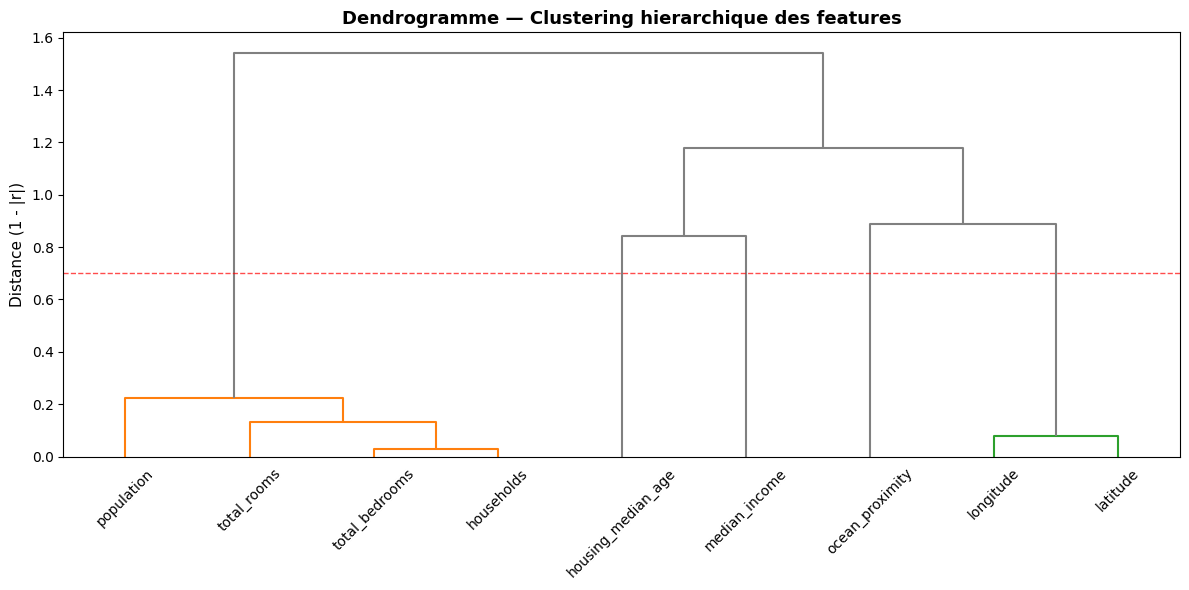

Lecture : les features qui fusionnent a faible distance sont fortement correlees.
Les groupes identiques a l'analyse de colinearite apparaissent clairement.


In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Matrice de distance basee sur la correlation : d = 1 - |r|
corr_matrix = df[features].corr().abs()
distance_matrix = 1 - corr_matrix

# Conversion en forme condensee pour scipy
dist_condensed = squareform(distance_matrix, checks=False)

# Clustering hierarchique (methode de Ward)
linked = linkage(dist_condensed, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendro = dendrogram(
    linked,
    labels=features,
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.7,
    above_threshold_color='gray',
)

ax.set_ylabel('Distance (1 - |r|)', fontsize=11)
ax.set_title('Dendrogramme — Clustering hierarchique des features', fontweight='bold', fontsize=13)
ax.axhline(y=0.7, color='red', linestyle='--', lw=1, alpha=0.7, label='Seuil colinearite (|r| > 0.8 => d < 0.2)')

plt.tight_layout()
plt.show()

print("Lecture : les features qui fusionnent a faible distance sont fortement correlees.")
print("Les groupes identiques a l'analyse de colinearite apparaissent clairement.")

## 2. Train / Test split (70/30)

In [19]:
X = df[features_clean].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {X_train.shape[0]} echantillons ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} echantillons ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 12320 echantillons (70%)
Test  : 5281 echantillons (30%)


## 3. Random Forest Regressor

Le Random Forest est un **ensemble** de $B$ arbres de decision entraines sur des sous-echantillons aleatoires (bootstrap) des donnees. Chaque arbre vote, et la prediction finale est la **moyenne** des predictions individuelles :

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

**Avantages** par rapport a la regression lineaire :
- Capture les relations **non lineaires** entre features et cible
- Robuste aux outliers et au bruit
- Pas besoin de normalisation (mais on utilise les donnees deja nettoyees)

**Hyperparametres** :
- `n_estimators` : nombre d'arbres (100)
- `max_depth` : profondeur maximale de chaque arbre (None = pas de limite)
- `random_state` : graine aleatoire (42)

In [20]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

print(f"Nombre d'arbres       : {model.n_estimators}")
print(f"Profondeur max        : {model.max_depth or 'illimitee'}")
print(f"Features par split    : {model.max_features}")
print(f"Nombre de features    : {model.n_features_in_}")

Nombre d'arbres       : 100
Profondeur max        : illimitee
Features par split    : 1.0
Nombre de features    : 5


### Architecture du Random Forest

Vue d'ensemble : les 5 features entrent dans $B$ arbres independants (entraines sur des echantillons bootstrap). Chaque arbre produit une prediction, et la **moyenne** donne le resultat final.

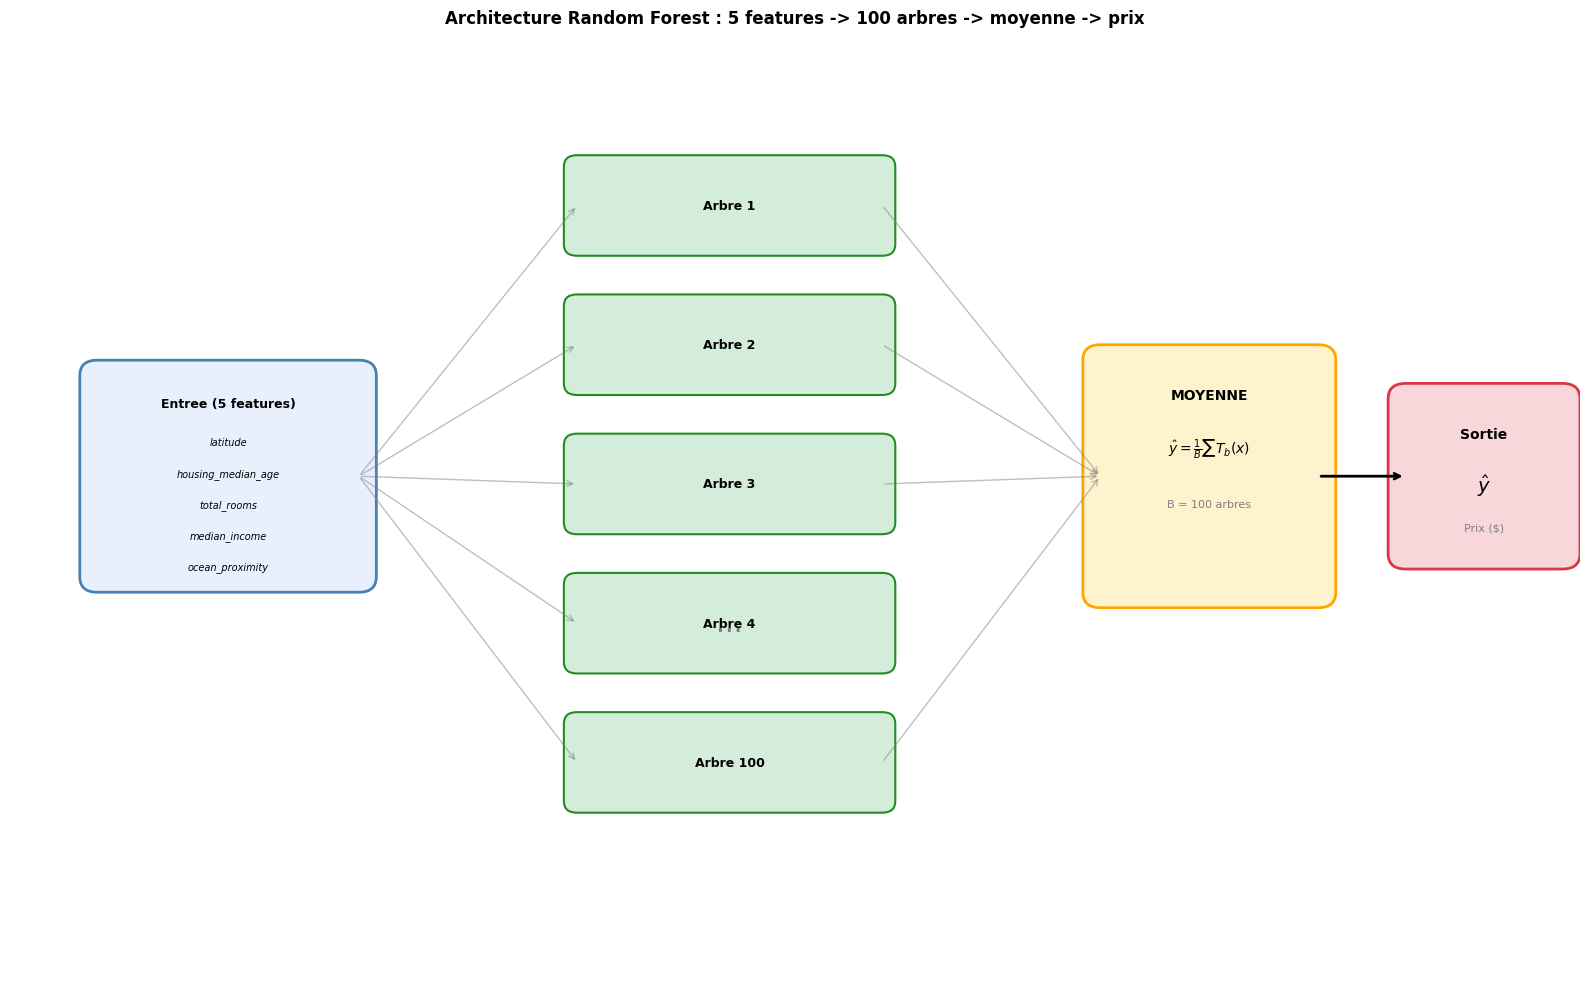

In [21]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')
ax.set_xlim(-1, 17)
ax.set_ylim(-1, 11)

# --- Input block ---
input_box = FancyBboxPatch((0, 4.2), 3, 2.6, boxstyle="round,pad=0.2", fc='#e8f0fe', ec='steelblue', lw=2)
ax.add_patch(input_box)
ax.text(1.5, 6.4, 'Entree (5 features)', ha='center', fontweight='bold', fontsize=9)
for j, feat in enumerate(features_clean):
    ax.text(1.5, 5.9 - j * 0.4, feat, ha='center', fontsize=7, fontstyle='italic')

# --- Tree blocks ---
n_trees_show = 5
tree_x = 5.5
tree_spacing = 1.8
tree_y_start = 9.0

for t in range(n_trees_show):
    y = tree_y_start - t * tree_spacing
    box = FancyBboxPatch((tree_x, y - 0.5), 3.5, 1.0, boxstyle="round,pad=0.15",
                          fc='#d4edda', ec='forestgreen', lw=1.5)
    ax.add_patch(box)
    if t < n_trees_show - 1:
        ax.text(tree_x + 1.75, y, f'Arbre {t+1}', ha='center', va='center', fontweight='bold', fontsize=9)
    else:
        ax.text(tree_x + 1.75, y, f'Arbre {model.n_estimators}', ha='center', va='center', fontweight='bold', fontsize=9)
    
    # Arrow from input to tree
    ax.annotate('', xy=(tree_x, y), xytext=(3, 5.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.5))

# Dots between tree 4 and tree 100
dots_y = tree_y_start - 3 * tree_spacing
ax.text(tree_x + 1.75, dots_y, '...', ha='center', va='center', fontsize=20, color='gray')

# --- Moyenne block ---
avg_x = 11.5
avg_box = FancyBboxPatch((avg_x, 4.0), 2.5, 3.0, boxstyle="round,pad=0.2", fc='#fff3cd', ec='orange', lw=2)
ax.add_patch(avg_box)
ax.text(avg_x + 1.25, 6.5, 'MOYENNE', ha='center', fontweight='bold', fontsize=10)
ax.text(avg_x + 1.25, 5.8, r'$\hat{y} = \frac{1}{B}\sum T_b(x)$', ha='center', fontsize=10)
ax.text(avg_x + 1.25, 5.1, f'B = {model.n_estimators} arbres', ha='center', fontsize=8, color='gray')

# Arrows from trees to average
for t in range(n_trees_show):
    y = tree_y_start - t * tree_spacing
    if t != 3:  # skip dots row
        ax.annotate('', xy=(avg_x, 5.5), xytext=(tree_x + 3.5, y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.5))

# --- Output block ---
out_x = 15
out_box = FancyBboxPatch((out_x, 4.5), 1.8, 2.0, boxstyle="round,pad=0.2", fc='#f8d7da', ec='#dc3545', lw=2)
ax.add_patch(out_box)
ax.text(out_x + 0.9, 6.0, 'Sortie', ha='center', fontweight='bold', fontsize=10)
ax.text(out_x + 0.9, 5.3, r'$\hat{y}$', ha='center', fontsize=14)
ax.text(out_x + 0.9, 4.8, 'Prix ($)', ha='center', fontsize=8, color='gray')

# Arrow from average to output
ax.annotate('', xy=(out_x, 5.5), xytext=(avg_x + 2.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.title('Architecture Random Forest : 5 features -> 100 arbres -> moyenne -> prix', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

### Visualisation d'un arbre individuel

On affiche l'**arbre n°0** de la foret, limite a une profondeur de 3 pour la lisibilite. Chaque noeud montre la condition de split, le nombre d'echantillons et la valeur predite.

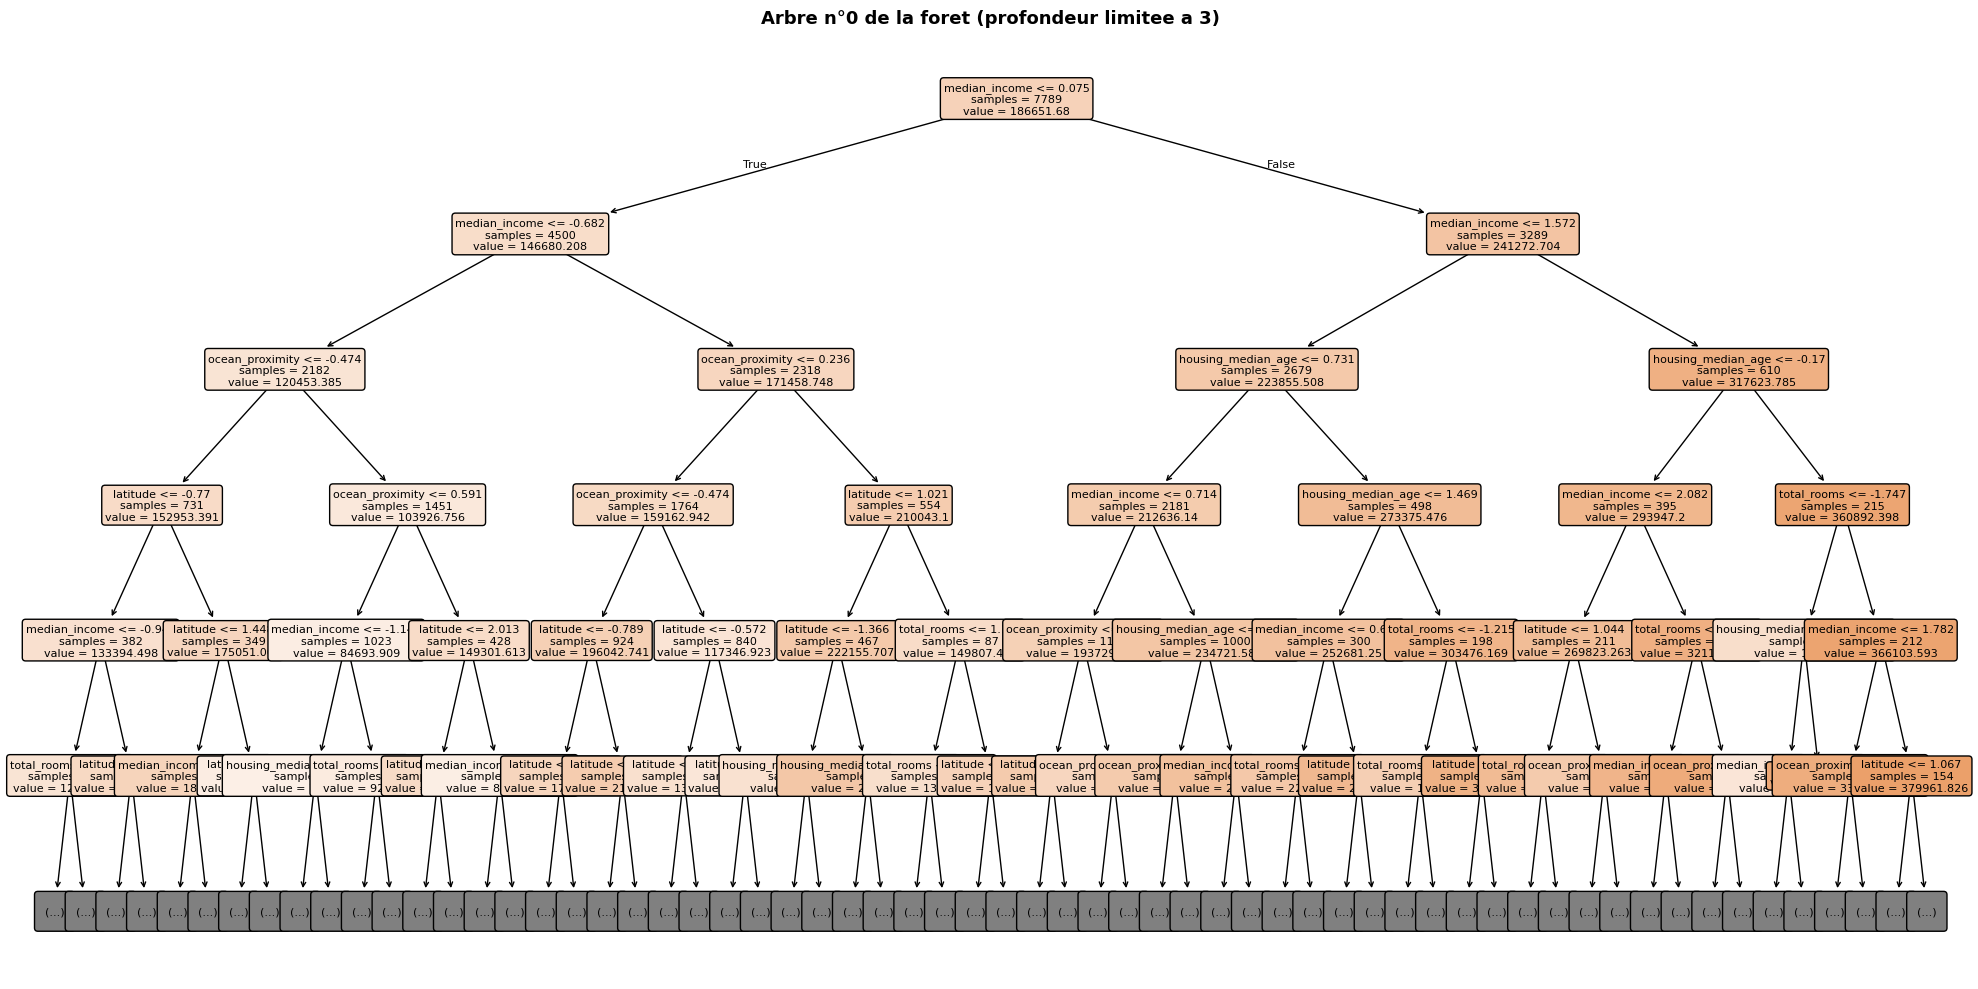

Profondeur des 100 arbres :
  Min : 28, Max : 38, Moyenne : 31.7


In [ ]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    max_depth=3,
    feature_names=features_clean,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
)
ax.set_title('Arbre n°0 de la foret (profondeur limitee a 3)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Stats sur la profondeur des arbres
depths = [est.get_depth() for est in model.estimators_]
print(f"Profondeur des {len(depths)} arbres :")
print(f"  Min : {min(depths)}, Max : {max(depths)}, Moyenne : {np.mean(depths):.1f}")

## 4. Importance des features

Le Random Forest mesure l'importance de chaque feature par la **reduction moyenne de l'impurete** (MDI — Mean Decrease in Impurity) qu'elle apporte dans les splits des arbres.

Importance des features :
  median_income             : 0.4761
  latitude                  : 0.1712
  ocean_proximity           : 0.1409
  housing_median_age        : 0.1065
  total_rooms               : 0.1054


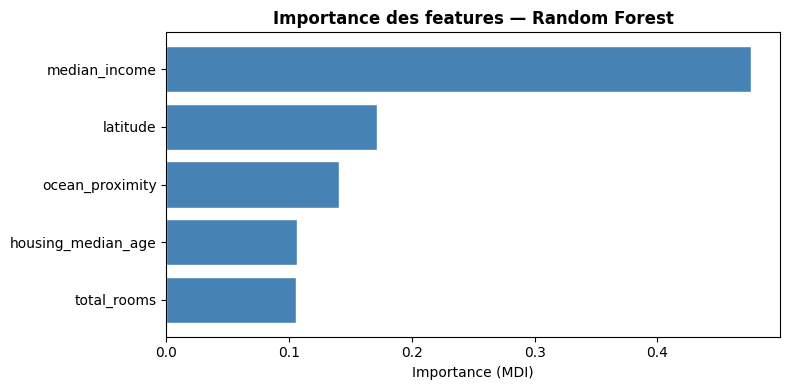

In [23]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Importance des features :")
for i in indices:
    print(f"  {features_clean[i]:25s} : {importances[i]:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([features_clean[i] for i in indices[::-1]], importances[indices[::-1]], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (MDI)')
ax.set_title('Importance des features — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Predictions

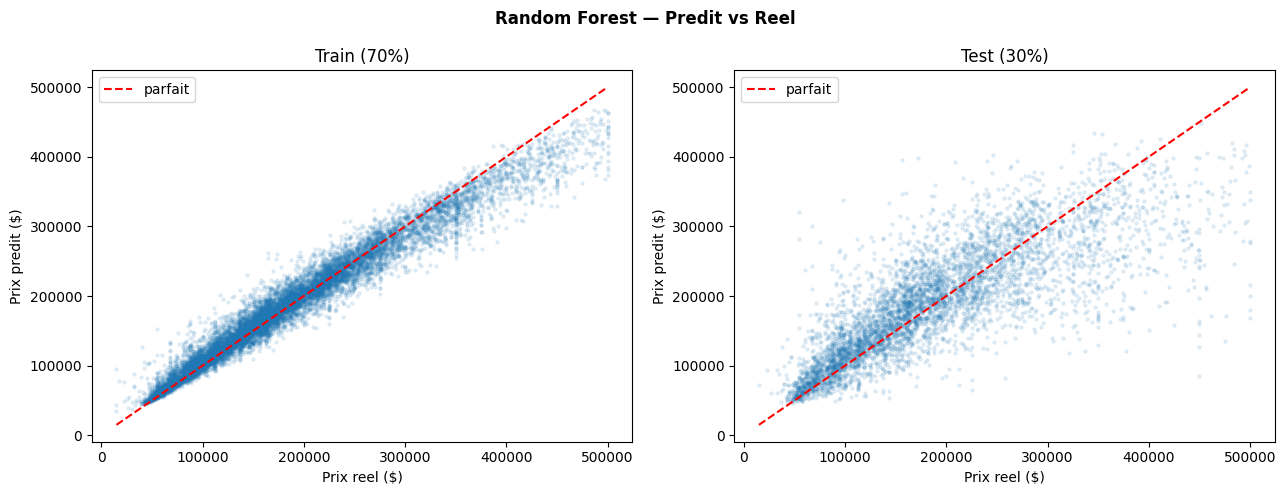

In [24]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Scatter plot : predit vs reel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_true, y_pred) in zip(axes, [('Train (70%)', y_train, y_pred_train), ('Test (30%)', y_test, y_pred_test)]):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=1.5, label='parfait')
    ax.set_xlabel('Prix reel ($)')
    ax.set_ylabel('Prix predit ($)')
    ax.set_title(f'{name}')
    ax.legend()
plt.suptitle('Random Forest — Predit vs Reel', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Evaluation de la precision — Moyenne et ecart-type des erreurs (en %)

On evalue la qualite du modele en analysant la **distribution des erreurs relatives** (residus en pourcentage) :

$$e_{\%,i} = \frac{y_i - \hat{y}_i}{y_i} \times 100$$

| Metrique | Formule | Interpretation |
|----------|---------|----------------|
| **Moyenne des erreurs (%)** | $\bar{e}_\% = \frac{1}{n}\sum \frac{e_i}{y_i} \times 100$ | Biais relatif du modele (0% = pas de biais systematique) |
| **Ecart-type des erreurs (%)** | $\sigma_{e\%} = \text{std}\left(\frac{e_i}{y_i} \times 100\right)$ | Dispersion relative des erreurs (plus bas = plus precis) |

In [25]:
def evaluer_erreurs(y_true, y_pred, nom):
    """Calcule et affiche la moyenne et l'ecart-type des erreurs en pourcentage."""
    erreurs_pct = ((y_true - y_pred) / y_true) * 100
    
    moyenne = np.mean(erreurs_pct)
    ecart_type = np.std(erreurs_pct)
    
    print(f"--- {nom} ---")
    print(f"  Moyenne des erreurs (biais)      : {moyenne:>+8.2f} %")
    print(f"  Ecart-type des erreurs (spread)   : {ecart_type:>8.2f} %")
    print(f"  Intervalle 68% (1 sigma)          : [{moyenne - ecart_type:>+.2f}%, {moyenne + ecart_type:>+.2f}%]")
    print(f"  Intervalle 95% (2 sigma)          : [{moyenne - 2*ecart_type:>+.2f}%, {moyenne + 2*ecart_type:>+.2f}%]")
    print()
    
    return erreurs_pct, moyenne, ecart_type

err_train, mu_train, std_train = evaluer_erreurs(y_train, y_pred_train, 'Train (70%)')
err_test, mu_test, std_test = evaluer_erreurs(y_test, y_pred_test, 'Test (30%)')

--- Train (70%) ---
  Moyenne des erreurs (biais)      :    -3.26 %
  Ecart-type des erreurs (spread)   :    13.95 %
  Intervalle 68% (1 sigma)          : [-17.22%, +10.69%]
  Intervalle 95% (2 sigma)          : [-31.17%, +24.65%]

--- Test (30%) ---
  Moyenne des erreurs (biais)      :    -8.55 %
  Ecart-type des erreurs (spread)   :    33.75 %
  Intervalle 68% (1 sigma)          : [-42.31%, +25.20%]
  Intervalle 95% (2 sigma)          : [-76.06%, +58.95%]



### Interpretation

- **Moyenne proche de 0%** : le modele ne surestime ni ne sous-estime systematiquement les prix.
- **Ecart-type** : mesure la precision effective du modele en %. Un ecart-type faible signifie que les predictions sont regroupees autour de la vraie valeur.
- **Intervalle a 1 sigma** : 68% des predictions ont une erreur relative dans cet intervalle.
- **Intervalle a 2 sigma** : 95% des predictions ont une erreur relative dans cet intervalle.

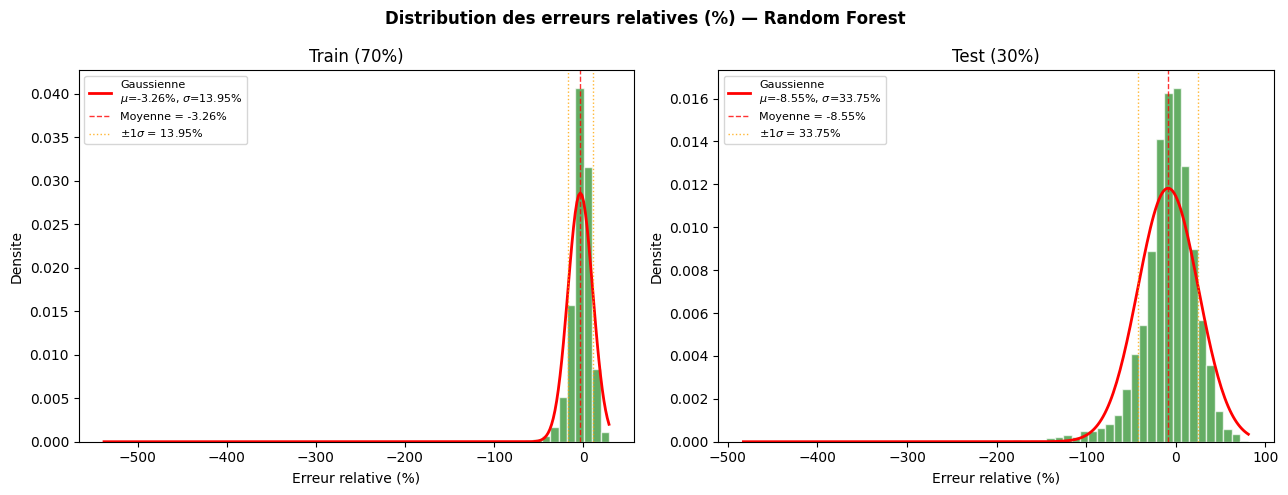

In [26]:
# Distribution des erreurs relatives (%)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nom, erreurs, mu, sigma) in zip(axes, [
    ('Train (70%)', err_train, mu_train, std_train),
    ('Test (30%)', err_test, mu_test, std_test)
]):
    ax.hist(erreurs, bins=60, density=True, alpha=0.7, color='forestgreen', edgecolor='white')
    
    # Courbe gaussienne theorique
    x = np.linspace(erreurs.min(), erreurs.max(), 300)
    gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, gauss, 'r-', lw=2, label=f'Gaussienne\n$\\mu$={mu:.2f}%, $\\sigma$={sigma:.2f}%')
    
    # Lignes verticales pour mu et sigma
    ax.axvline(mu, color='red', linestyle='--', lw=1, alpha=0.8, label=f'Moyenne = {mu:.2f}%')
    ax.axvline(mu - sigma, color='orange', linestyle=':', lw=1, alpha=0.8)
    ax.axvline(mu + sigma, color='orange', linestyle=':', lw=1, alpha=0.8, label=f'$\\pm 1\\sigma$ = {sigma:.2f}%')
    
    ax.set_xlabel('Erreur relative (%)')
    ax.set_ylabel('Densite')
    ax.set_title(f'{nom}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des erreurs relatives (%) — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Resume des resultats

$$R^2 = 1 - \frac{V(\text{reel})}{V(\text{theorique})} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

| Variable | Description |
|----------|-------------|
| $V(\text{reel}) = \sum(y_i - \hat{y}_i)^2$ | Variance residuelle : erreur reelle du modele |
| $V(\text{theorique}) = \sum(y_i - \bar{y})^2$ | Variance totale : dispersion des donnees autour de la moyenne |
| $y_i$ | Valeur reelle (prix median observe) pour l'echantillon $i$ |
| $\hat{y}_i$ | Valeur predite par le modele pour l'echantillon $i$ |
| $\bar{y}$ | Moyenne des valeurs reelles |

- $R^2 = 1$ : $V(\text{reel}) = 0$, prediction parfaite
- $R^2 = 0$ : le modele ne fait pas mieux que predire la moyenne $\bar{y}$
- $R^2 < 0$ : le modele fait pire que la moyenne

In [27]:
resume = pd.DataFrame({
    'Train': {
        'Moyenne erreurs (%)': mu_train,
        'Ecart-type erreurs (%)': std_train,
        'MAE ($)': mean_absolute_error(y_train, y_pred_train),
        'RMSE ($)': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'R2': r2_score(y_train, y_pred_train),
    },
    'Test': {
        'Moyenne erreurs (%)': mu_test,
        'Ecart-type erreurs (%)': std_test,
        'MAE ($)': mean_absolute_error(y_test, y_pred_test),
        'RMSE ($)': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'R2': r2_score(y_test, y_pred_test),
    }
})

print(resume.to_string(float_format=lambda x: f'{x:.2f}'))

print(f"\n--- Conclusion ---")
print(f"Le Random Forest a un ecart-type d'erreur de {std_test:.2f}% sur le jeu de test.")
print(f"68% des predictions sont a +/- {std_test:.2f}% du prix reel,")
print(f"et 95% des predictions sont a +/- {2*std_test:.2f}% du prix reel.")

                          Train     Test
Moyenne erreurs (%)       -3.26    -8.55
Ecart-type erreurs (%)    13.95    33.75
MAE ($)                14305.34 39541.67
RMSE ($)               20708.18 57188.75
R2                         0.95     0.64

--- Conclusion ---
Le Random Forest a un ecart-type d'erreur de 33.75% sur le jeu de test.
68% des predictions sont a +/- 33.75% du prix reel,
et 95% des predictions sont a +/- 67.50% du prix reel.


In [ ]:
# Graphique de synthese : erreur moyenne +/- ecart-type (%) pour train et test
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Train', 'Test']
moyennes = [mu_train, mu_test]
ecarts = [std_train, std_test]

x_pos = range(len(labels))
bars = ax.bar(x_pos, moyennes, yerr=ecarts, capsize=10, edgecolor='white', alpha=0.8, width=0.5)

ax.axhline(0, color='black', linestyle='-', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Erreur relative (%)')
ax.set_title('Moyenne $\\pm$ ecart-type des erreurs (%) — Random Forest', fontweight='bold')

for i, (m, s) in enumerate(zip(moyennes, ecarts)):
    ax.text(i, m + s + 1, f'$\\mu$={m:.2f}%\n$\\sigma$={s:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()